## Fórmula

1. Equação da reta: usada como base para relacionar as variáveis independentes com a saída.

2. Função Sigmoide: transforma o resultado da equação da reta em um valor entre 0 e 1, representando probabilidade.

3. Transformação Logit: aplica o logaritmo da razão de chances (odds) para permitir que o modelo ajuste a reta antes de aplicar novamente a sigmoide durante cada iteração.    

## Características

- É um algoritmo de classificação, não de regressão, apesar do nome.    

- Estima a probabilidade de um evento ocorrer com base nas variáveis independentes.

- É especialmente eficiente para classificação binária (0 ou 1).

- O modelo aprende uma reta separadora entre as classes e usa a sigmoide para converter essa reta em probabilidades.

- A decisão final (classe prevista) é feita a partir do limiar padrão de 0,5, podendo ser ajustado conforme necessidade. 

## Hiperparâmetro


C (inverso da regularização) → controla a intensidade da regularização aplicada ao modelo. 
Valores baixos de C aumentam a regularização; valores altos reduzem a regularização.

max_iter → número máximo de interações (quantas vezes o algoritmo vai tentar fazer a reta antes de encontrar a melhor)

## Funcionamento Funções

1. Sigmoide (logistic)

Usada quando existem duas classes (0 e 1).

Transforma valores em probabilidades entre 0 e 1.

2. Softmax (multinomial)

Usada quando existem múltiplas classes (ex.: 0, 1, 2, 3...).

Cada classe recebe uma probabilidade, e a soma de todas é 1.

3. Outras funções (menos comuns no sklearn)

Probit

Complementary log-log (cloglog)    

## Código

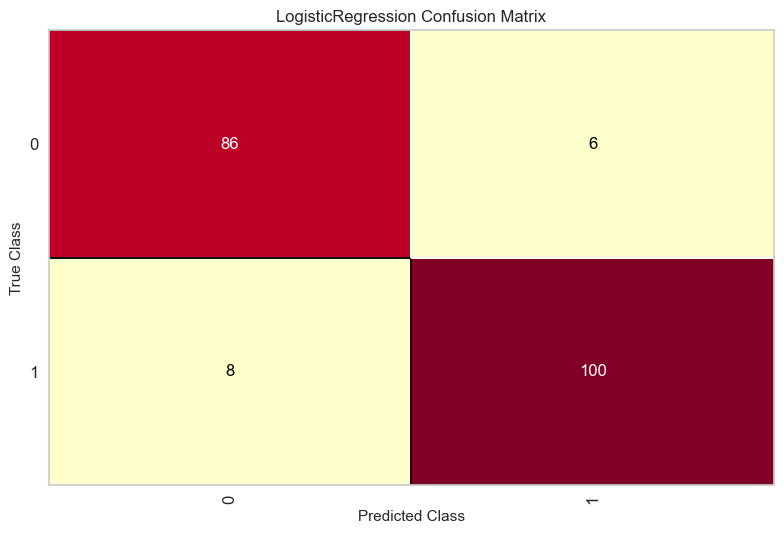

Predições: [0 0 0 0 1 0 1 1 1 0]

Accuracy: 0.93


In [1]:
# ===============================
# 1. Criar base de dados local (sintética)
# ===============================
from sklearn.datasets import make_classification  # import usado apenas aqui

X, y = make_classification(
    n_samples=1000,        # quantidade de amostras
    n_features=5,          # número de variáveis independentes
    n_informative=3,       # features realmente importantes
    n_redundant=0,         # features derivadas
    n_classes=2,           # classificação binária
    random_state=42        # garante repetibilidade
)


# ===============================
# 2. Separar treino e teste
# ===============================
from sklearn.model_selection import train_test_split  # import acima do uso

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% dos dados para teste
    random_state=42        # mesma divisão sempre
)


# ===============================
# 3. Criar e treinar o modelo (Regressão Logística)
# ===============================
from sklearn.linear_model import LogisticRegression  # import acima do uso

modelo = LogisticRegression(max_iter=200)  # aumenta iterações para evitar warnings
modelo.fit(X_train, y_train)


# ===============================
# 4. Fazer previsões
# ===============================
y_pred = modelo.predict(X_test)


# ===============================
# 5. Calcular Accuracy
# ===============================
from sklearn.metrics import accuracy_score  # import acima do uso

accuracy = accuracy_score(y_test, y_pred)


# ===============================
# 6. Confusion Matrix (Yellowbrick)
# ===============================
from yellowbrick.classifier import ConfusionMatrix  # import acima do uso

cm = ConfusionMatrix(modelo)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)
cm.show()


# ===============================
# 7. Exibir resultados
# ===============================
print("Predições:", y_pred[:10])
print("\nAccuracy:", accuracy)